In [1]:
import numpy as np
import scipy as sp
import scipy.stats as stats
import matplotlib.pyplot as plt

import sympy as smp

In [2]:
import qiskit
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.visualization import plot_histogram


root2 = np.sqrt(2)

Simple rank 2 tensor determinant (2x2 matrix)

$
\begin{bmatrix}
    a & b \\\\
    c & d 
\end{bmatrix}
$

$|det M|^2$

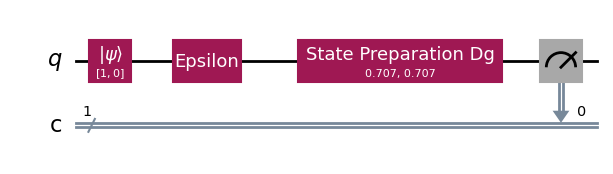

In [3]:
ψ = Statevector([1, 0])
φ = Statevector([1/root2, 1/root2])

V_dag = StatePreparation(φ).inverse()

antisym = UnitaryGate([
    [0, 1],
    [-1, 0]
])
antisym.name = "εpsilon"

circ = QuantumCircuit(1, 1)

circ.initialize(ψ)
circ.compose(antisym, inplace=True)
circ.compose(V_dag, inplace=True)

circ.measure(0, 0)
circ.draw('mpl')

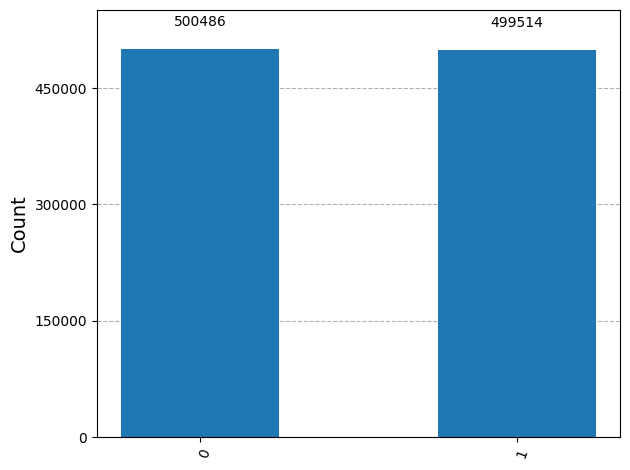

In [4]:
sampler = StatevectorSampler()
job = sampler.run([circ], shots=1_000_000)

res = job.result()[0]
counts = res.data.c.get_counts()
plot_histogram(counts)

$P(0) = |det M|^2$

- When P(0) > P(1), the determinant is non-zero

Hadamard Primitive

In [5]:
ψ = Statevector([1, 0])
φ = Statevector([1/root2, 1/root2])

rand_u = stats.unitary_group.rvs(2)

rand_u

array([[-0.09391199-0.14569344j, -0.87796425-0.44624291j],
       [ 0.66905773+0.72271413j, -0.16580282-0.05055164j]])

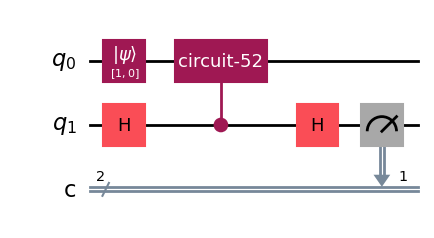

In [6]:


V_dag = StatePreparation(φ).inverse()

antisym = UnitaryGate([
    [0, 1],
    [-1, 0]
])
antisym.name = "εpsilon"

sub = QuantumCircuit(1)
sub.compose(antisym, inplace=True)
sub.compose(V_dag, inplace=True)

detGate = sub.to_gate()
CdetGate = detGate.control(1)

qc = QuantumCircuit(2, 2)
qc.initialize(ψ, 0)
qc.h(1)
qc.compose(CdetGate, qubits=[1, 0], inplace=True)
qc.h(1)

qc.measure(1, 1)

qc.draw('mpl')

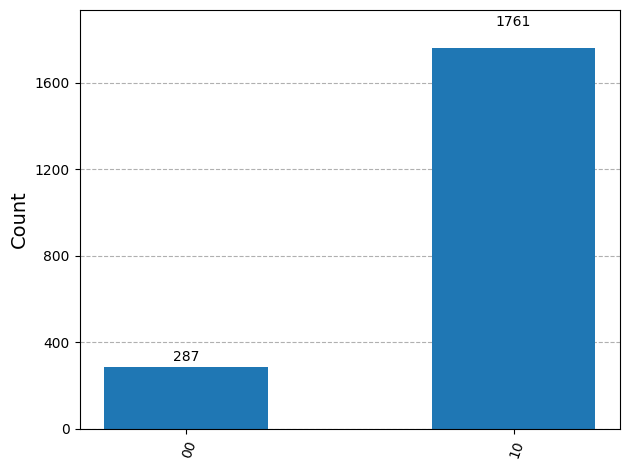

In [7]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=2048)

res = job.result()[0]
counts = res.data.c.get_counts()
plot_histogram(counts)

In [8]:
counts

{'10': 1761, '00': 287}

In [9]:
p0 = (counts['10'] / 2048)# * 100
print(f"P(0) = {p0 * 100}%, Determinant: {2 * p0 - 1}")

P(0) = 85.986328125%, Determinant: 0.7197265625


In [19]:
def quantum_determinant(mat: np.ndarray, shots=2048) -> float:
    
    ψ = mat[:, 0]
    φ = mat[:, 1]

    print(f"Psi: {ψ}\nPhi: {φ}")

    # V^dagger |φ> = |0> -> V^dagger projects phi onto the computational basis 
    V_dag = StatePreparation(φ).inverse()

    # antisymmetric tensor, ε 
    antisym = UnitaryGate([
        [0, 1],
        [-1, 0]
    ])

    # compose ε and Vdag together to make controlled U gate
    sub = QuantumCircuit(1)
    sub.compose(antisym, inplace=True)
    sub.compose(V_dag, inplace=True)

    # control
    detGate = sub.to_gate()
    CdetGate = detGate.control(1)  

    # form full circuit w/ hadamard test 
    qc = QuantumCircuit(2, 2)
    qc.initialize(ψ, 0)
    qc.h(1)
    qc.compose(CdetGate, qubits=[1, 0], inplace=True)
    qc.h(1)

    # measure ancilla qubit
    qc.measure(1, 1)

    print(qc)

    # get results -> detM from P(0) 

    det = lambda p0: 2 * p0 - 1

    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=shots)

    print(f"Running circuit simulation with {shots} shots")

    res = job.result()[0]
    counts = res.data.c.get_counts()

    print(f"Counts dict: {counts}")
    for k, v in counts.items():
        print(k + ":")
        print(f"  Prob: {(v / shots) * 100}%")
        print(f"  Determinant = {det(v / shots)}")
    print()
    print(f"Quantum Determinant: {det(counts['00'] / shots)}")
    print(f"Determinant (ad-bc): {np.linalg.det(mat)}")

    return counts


Psi: [0.70710678 0.70710678]
Phi: [ 0.70710678 -0.70710678]
     ┌─────────────────────────────┐┌─────────────┐        
q_0: ┤ Initialize(0.70711,0.70711) ├┤ circuit-333 ├────────
     └────────────┬───┬────────────┘└──────┬──────┘┌───┐┌─┐
q_1: ─────────────┤ H ├────────────────────■───────┤ H ├┤M├
                  └───┘                            └───┘└╥┘
c: 2/════════════════════════════════════════════════════╩═
                                                         1 
Running circuit simulation with 4096 shots
Counts dict: {'00': 3520, '10': 576}
00:
  Prob: 85.9375%
  Determinant = 0.71875
10:
  Prob: 14.0625%
  Determinant = -0.71875

Quantum Determinant: 0.71875
Determinant (ad-bc): -0.9999999999999998


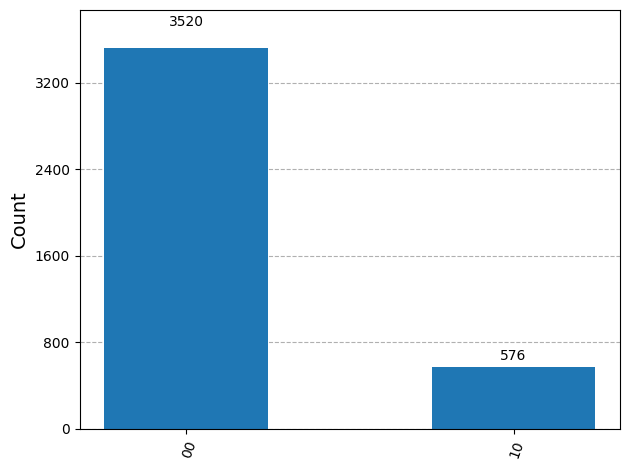

In [29]:
counts = quantum_determinant(np.array([
    [1/root2, 1/root2],
    [1/root2, -1/root2]
]), shots=4096)

plot_histogram(counts)

# Cayley Hyperdeterminants

Now move onto calculating actual Cayley Hyperdeterminants for a 2x2x2 3 qubit system using Pauli expectation values

$Det_3 A = -2^4 (\langle YYI \rangle^2 - \langle YYX \rangle^2 - \langle YYZ \rangle^2)$

In [12]:
pauli_observables = np.array([
    SparsePauliOp("YYI"),
    SparsePauliOp("YYX"),
    SparsePauliOp("YYZ")
])

root2 = np.sqrt(2)
root3 = np.sqrt(3)
root8 = np.sqrt(8)

state = np.ones(8) / root8

GHZ = np.array([
    [root2],
    [0],
    [0],
    [0],
    [0],
    [0],
    [0],
    [root2],
])

W = np.array([
    [0],        # 000
    [root3],    # 001
    [root3],    # 010
    [0],        # 011
    [root3],    # 100
    [0],
    [0],
    [0],        # 111
])

estimator = StatevectorEstimator()

qc = QuantumCircuit(3, 3)
qc.initialize(Statevector(state), [0, 1, 2])
print(qc)

job = estimator.run([(qc, pauli_observables[0]), (qc, pauli_observables[1]), (qc, pauli_observables[2])])


     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
c: 3/»
     »
«     ┌──────────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                             ├
«     │                                                                              │
«q_1: ┤1 Initialize(0.35355,0.35355,0.35355,0.35355,0.35355,0.35355,0.35355,0.35355) ├
«     │                                                                              │
«q_2: ┤2                                                                             ├
«     └──────────────────────────────────────────────────────────────────────────────┘
«c: 3/════════════════════════════════════════════════════════════════════════════════
«                                                                                     


TypeError: Invalid observable type: <class 'complex'>